In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df = pd.read_csv('/content/df_final.csv')
df[['pid', 'meno', 'grade', 'hormon', 'chemo', 'recur', 'death', 'status']] = df[['pid', 'meno', 'grade', 'hormon', 'chemo', 'recur', 'death', 'status']].astype(object)
df.drop('Unnamed: 0', axis = 1, inplace = True)

df['survival_probability%'] = (df['survival_probability%']*100).round(2)

print(df.info())
df.sample(6)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2982 entries, 0 to 2981
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   pid                    2982 non-null   object 
 1   year                   2982 non-null   int64  
 2   age                    2982 non-null   int64  
 3   meno                   2982 non-null   object 
 4   size                   2982 non-null   object 
 5   grade                  2982 non-null   object 
 6   nodes                  2982 non-null   int64  
 7   pgr                    2982 non-null   int64  
 8   er                     2982 non-null   int64  
 9   hormon                 2982 non-null   object 
 10  chemo                  2982 non-null   object 
 11  rtime                  2982 non-null   int64  
 12  recur                  2982 non-null   object 
 13  dtime                  2982 non-null   int64  
 14  death                  2982 non-null   object 
 15  stat

,pid,year,age,meno,size,grade,nodes,pgr,er,hormon,chemo,rtime,recur,dtime,death,status,rtime_yrs,treatment,dtime_yrs,survival_probability%
633,640,1993,51,0,<=20,2,0,38,79,0,0,2414,0,2414,0,0,6.609172,placebo,6.613699,58.75
20,21,1993,57,1,<=20,3,1,4,271,1,0,851,0,851,0,0,2.329911,drugA,2.331507,77.18
1917,1935,1986,68,1,20-50,3,0,77,305,0,0,229,1,751,1,1,0.626968,placebo,2.057534,79.65
2981,3007,1993,68,1,<=20,3,12,0,0,1,0,379,1,379,1,1,1.037645,placebo,1.038356,91.29
2636,2661,1990,32,0,20-50,3,0,3,1,0,0,721,1,895,1,1,1.973990,drugA,2.452055,76.20
1653,1670,1985,49,0,20-50,3,11,0,16,1,1,691,1,1076,1,1,1.891855,placebo,2.947945,72.31


In [81]:
sns.color_palette

<function seaborn.palettes.color_palette(palette=None, n_colors=None, desat=None, as_cmap=False)>

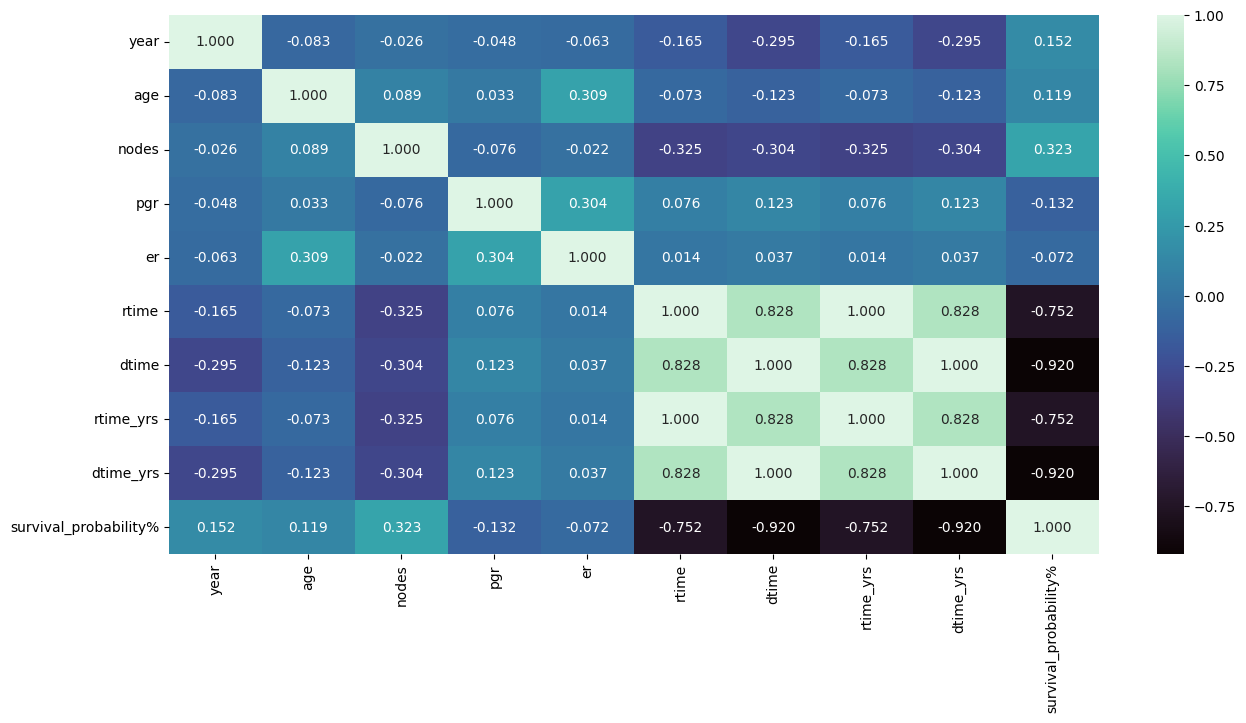

In [85]:
plt.figure(figsize = (15, 7))
sns.heatmap(df.corr(numeric_only = True), annot = True, fmt = '.3f', cmap = 'mako')
plt.show()

I Suspected that the Older a Person was when She got Surgery for Breast Cancer, the less the Survival Probability. But wait?

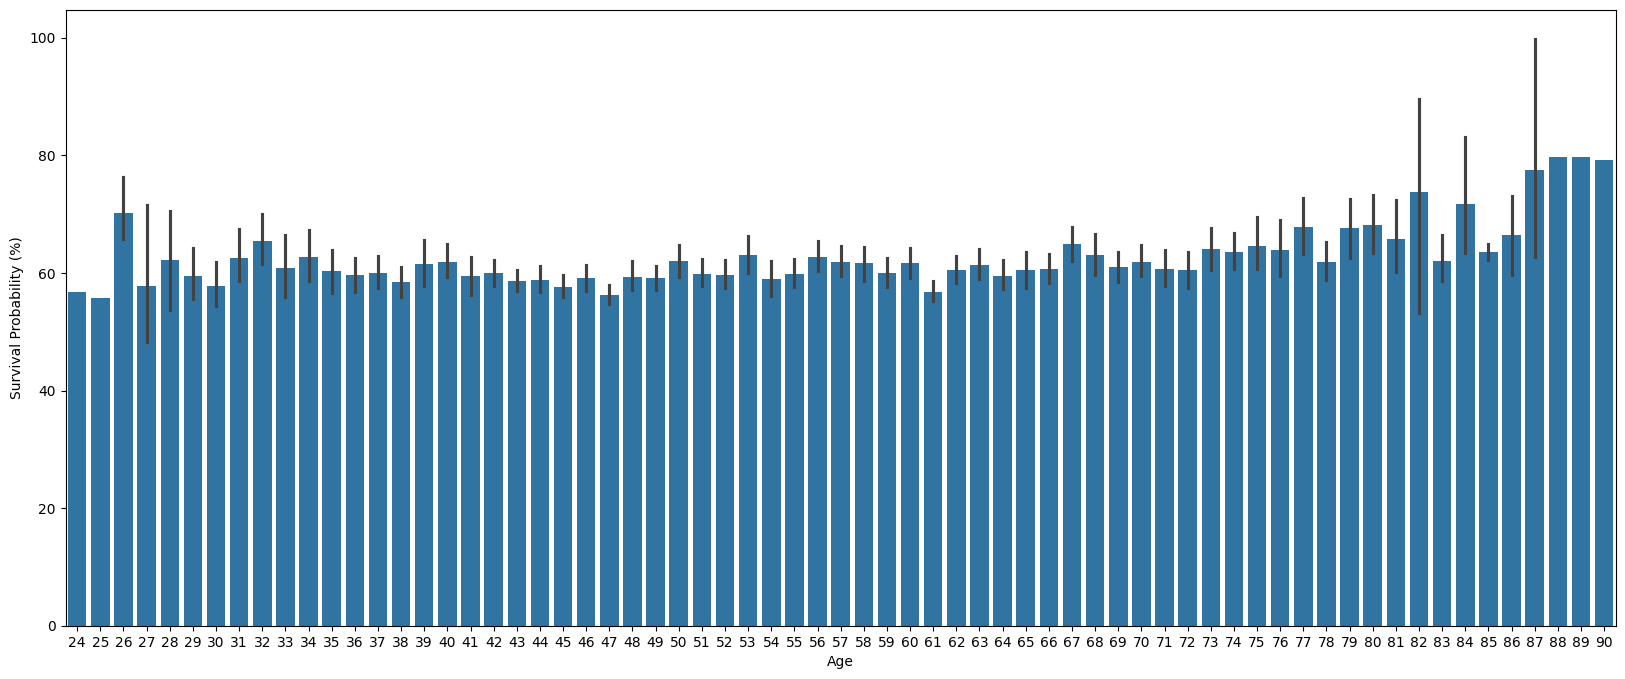

In [86]:
plt.figure(figsize = (20, 8))
sns.barplot(x = df['age'], y = df['survival_probability%'])
plt.xlabel('Age')
plt.ylabel('Survival Probability (%)')
plt.show()

## Let's see if there really is a Difference in Patient Survival Outcomes based on the Type of Treatment - Hormonal or Chemo:

**Chi-Squared Test of Independence**:

In [57]:
# Contingency Table for Both Types of Treatments - Hormonal and Chemotherapy

# Binning Survival Times (Days to Death) into 4 Categories
df['dtime_quantile'] = pd.qcut(df['dtime'], q = 4, labels = ['Survival Time - Q1', 'Survival Time - Q2', 'Survival Time - Q3', 'Survival Time - Q4'])
# df.sample(5)

# Contingency Tables for each Type of Treatment and the Lifetimes of Patients who Received them
ct1 = pd.crosstab(index = df['hormon'], columns = df['dtime_quantile'], values = df['dtime_quantile'], aggfunc = 'count')
ct2 = pd.crosstab(index = df['chemo'], columns = df['dtime_quantile'], values = df['dtime_quantile'], aggfunc = 'count')

# Building a Final, Aggregated Contingency Table
ct = pd.concat([ct1, ct2])

ct = ct.reset_index().set_index([['hormon', 'hormon', 'chemo', 'chemo']])

ct.rename(columns = {'dtime_quantile': 'treatment', 'index': 'given_or_not'}, inplace = True)
ct

dtime_quantile,given_or_not,Survival Time - Q1,Survival Time - Q2,Survival Time - Q3,Survival Time - Q4
hormon,0,630,616,680,717
hormon,1,118,127,65,29
chemo,0,596,593,613,600
chemo,1,152,150,132,146


In [106]:
from scipy.stats import chi2_contingency

# Extract the contingency table for hormonal treatment
ct_hormon = ct.loc['hormon', ['Survival Time - Q1', 'Survival Time - Q2', 'Survival Time - Q3', 'Survival Time - Q4']]

# Perform Chi-Squared test for hormonal treatment
chi2_hormon, p_hormon, dof_hormon, expected_hormon = chi2_contingency(ct_hormon)

print("Chi-Squared Test for Hormonal Treatment and Survival Outcomes:")
print(f"Chi2 Statistic: {chi2_hormon:.3f}")
print(f"P-value: {p_hormon:.3f}")
print(f"Degrees of Freedom: {dof_hormon}")

horm_total = pd.concat([ct_hormon, pd.DataFrame(expected_hormon,
                                   columns = ['Survival Time - Q1', 'Survival Time - Q2', 'Survival Time - Q3',
                                              'Survival Time - Q4'])]).round(1).astype(int)

horm_total.index = ['actual_hormonal_notgiven', 'actual_hormonal_given', 'expected_hormonal_notgiven', 'expected_hormonal_given']

display("Actual VS Expected Frequencies:", horm_total)

# Interpreting the Result for Hormonal Treatment
if p_hormon < 0.05: # The Alpha (Significance) level is 0.05
    print(f"\nSince the P-value ({p_hormon:.3f}) is less than the Significance level ({alpha}), we Reject the Null Hypothesis.\nThis suggests a statistically significant association between hormonal treatment and survival outcomes.")
else:
    print(f"\nSince the P-value ({p_hormon:.3f}) is greater than the Significance level ({alpha}), we fail to Reject the null hypothesis.\nThis suggests no statistically significant association between hormonal treatment and survival outcomes.")

Chi-Squared Test for Hormonal Treatment and Survival Outcomes:
Chi2 Statistic: 85.186
P-value: 0.000
Degrees of Freedom: 3


'Actual VS Expected Frequencies:'

,Survival Time - Q1,Survival Time - Q2,Survival Time - Q3,Survival Time - Q4
actual_hormonal_notgiven,630,616,680,717
actual_hormonal_given,118,127,65,29
expected_hormonal_notgiven,663,658,660,661
expected_hormonal_given,85,84,84,84



Since the P-value (0.000) is less than the significance level (0.05), we reject the null hypothesis.
This suggests a statistically significant association between hormonal treatment and survival outcomes.


In [108]:
from scipy.stats import chi2_contingency

# Extracting the Contingency Table for Chemotherapy treatment
ct_chemo = ct.loc['chemo', ['Survival Time - Q1', 'Survival Time - Q2', 'Survival Time - Q3', 'Survival Time - Q4']]

# Performing a Chi-Squared test for Chemotherapy treatment
chi2_chemo, p_chemo, dof_chemo, expected_chemo = chi2_contingency(ct_chemo)

print("\nChi-Squared Test for Chemotherapy Treatment and Survival Outcomes:")
print(f"Chi2 Statistic: {chi2_chemo:.3f}")
print(f"P-value: {p_chemo:.3f}")
print(f"Degrees of Freedom: {dof_chemo}")

chemo_total = pd.concat([ct_chemo, pd.DataFrame(expected_chemo,
                                   columns = ['Survival Time - Q1', 'Survival Time - Q2', 'Survival Time - Q3',
                                              'Survival Time - Q4'])]).round(1).astype(int)

chemo_total.index = ['actual_chemo_notgiven', 'actual_chemo_given', 'expected_chemo_notgiven', 'expected_chemo_given']

display("Actual VS Expected Frequencies:", chemo_total)

# Interpreting the result for Chemotherapy treatment
if p_chemo < 0.05:
    print(f"\nSince the P-value ({p_chemo:.3f}) is less than the significance level ({alpha}), we reject the Null hypothesis.\nThis suggests a statistically significant association between chemotherapy treatment and survival outcomes.")
else:
    print(f"\nSince the P-value ({p_chemo:.3f}) is greater than the significance level ({alpha}), we fail to reject the Null hypothesis.\nThis suggests no statistically significant association between chemotherapy treatment and survival outcomes.")


Chi-Squared Test for Chemotherapy Treatment and Survival Outcomes:
Chi2 Statistic: 2.054
P-value: 0.561
Degrees of Freedom: 3


'Actual VS Expected Frequencies:'

,Survival Time - Q1,Survival Time - Q2,Survival Time - Q3,Survival Time - Q4
actual_chemo_notgiven,596,593,613,600
actual_chemo_given,152,150,132,146
expected_chemo_notgiven,602,598,600,600
expected_chemo_given,145,144,144,145



Since the P-value (0.561) is greater than the significance level (0.05), we fail to reject the Null hypothesis.
This suggests no statistically significant association between chemotherapy treatment and survival outcomes.


This is HUGE!^ **Chemotherapy** Does NOT have an Affect on Survival Outcomes!